# Does Work
### 17-07-2026 Does not need any changes

# 4.17 S21 simulation and fitting of a resonator

Authors: Samarth Hawaldar, Arvind Mamgain

Adapted from tutorial 4.16


> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.1 Quick start](../1-Overview/1.1-Quick-start.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../../docs/headless-usage.rst) for the full reference.

In [1]:
# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw, view
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import (
    LaunchpadWirebondDriven,
)
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

In [2]:
import numpy as np

## Set up the design

In [3]:
# Set up chip dimensions
design = designs.DesignPlanar()
design._chips["main"]["size"]["size_x"] = "9mm"
design._chips["main"]["size"]["size_y"] = "9mm"
design._chips["main"]["size"]["size_z"] = "-280um"
# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables["cpw_width"] = "10 um"  # S from reference 2
design.variables["cpw_gap"] = "6 um"  # W from reference 2


design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
# gui = MetalGUI(design)

In [4]:
# Define for renderer
eig_qres = EPRanalysis(design, "hfss")
# hfss = design.renderers.hfss
hfss = eig_qres.sim.renderer
q3d = design.renderers.q3d

## Define the geometry

Here we will have a single feedline couple to a single CPW resonator.

The lauchpad should be included in the driven model simulations.

For that reason, we use the LaunchpadWirebondDriven component which has an extra pin for input/output

In [5]:
###################
# Single feedline #
###################

# Driven Lauchpad 1
x = "-0.5mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="360", lead_length="30um"
)
LP1 = LaunchpadWirebondDriven(design, "LP1", options=launch_options)

# Driven Launchpad 2
x = "0.5mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="180", lead_length="30um"
)
LP2 = LaunchpadWirebondDriven(design, "LP2", options=launch_options)

# coupling resonator to feedline
q_read = CoupledLineTee(
    design,
    "Q_Read_T",
    options=dict(
        pos_x="0.0mm",
        pos_y="2mm",
        orientation="0",
        coupling_space="6um",
        coupling_length="300um",
        open_termination=False,
    ),
)


# gui.rebuild()

In [6]:
# Using path finder to connect the two launchpads
TL_LP1_T = RoutePathfinder(
    design,
    "TL_LP1_T",
    options=dict(
        chip="main",
        trace_width="10um",
        trace_gap="6um",
        fillet="99um",
        hfss_wire_bonds=True,
        lead=dict(end_straight="0.1mm"),
        pin_inputs=Dict(
            start_pin=Dict(component="LP1", pin="tie"),
            end_pin=Dict(component="Q_Read_T", pin="prime_start"),
        ),
    ),
)

TL_T_LP2 = RoutePathfinder(
    design,
    "TL_T_LP2",
    options=dict(
        chip="main",
        trace_width="10um",
        trace_gap="6um",
        fillet="99um",
        hfss_wire_bonds=True,
        lead=dict(end_straight="0.1mm"),
        pin_inputs=Dict(
            start_pin=Dict(component="Q_Read_T", pin="prime_end"),
            end_pin=Dict(component="LP2", pin="tie"),
        ),
    ),
)
# # Rebuild the GUI

In [7]:
######################
# lambda/4 resonator #
######################

# First we define the two end-points
otg = OpenToGround(
    design,
    "otg",
    options=dict(chip="main", pos_x="0.0mm", pos_y="0.8mm", orientation="-90"),
)

# Use RouteMeander to fix the total length of the resonator
rt_meander = RouteMeander(
    design,
    "meander",
    Dict(
        trace_width="10um",
        trace_gap="6um",
        total_length="3.7mm",
        hfss_wire_bonds=True,
        fillet="99 um",
        lead=dict(start_straight="250um"),
        pin_inputs=Dict(
            start_pin=Dict(component="otg", pin="open"),
            end_pin=Dict(component="Q_Read_T", pin="second_end"),
        ),
    ),
)

# rebuild the GUI
# gui.rebuild()

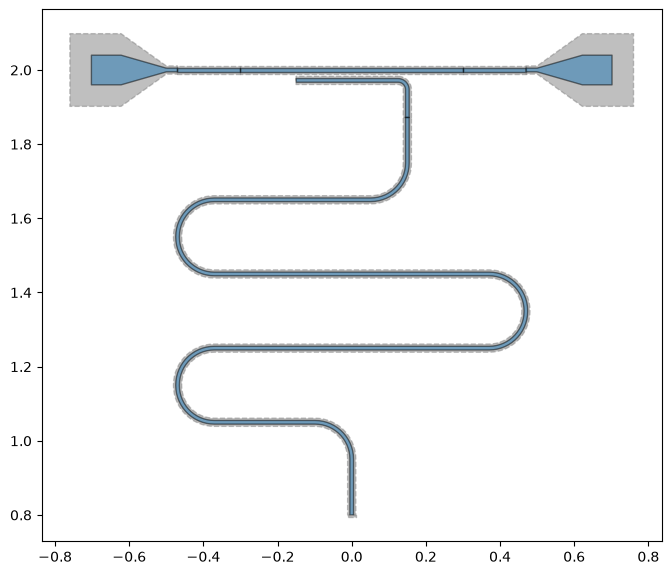

In [8]:
# gui.autoscale()
# gui.screenshot()
view(design)

## Scattering Analysis

In [9]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim

em1 = ScatteringImpedanceSim(design, "hfss")

In [10]:
design_name = "Sweep_DrivenModal"
qcomp_render = []  # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [("LP1", "in", 50), ("LP2", "in", 50)]
box_plus_buffer = True

In [11]:
em1.setup.name = "Sweep_DrivenModal_setup"
em1.setup.freq_ghz = 6.0  # Try to keep this at the center of the swept frequency range for 'fast' sweeps and at the largest frequency for interpolating sweep for the best results
em1.setup.max_delta_s = 0.005  # This is necessary to get good results if interpolating sweep is not working for you
em1.setup.max_passes = 18
em1.setup.min_passes = 2
em1.setup.basis_order = -1  # Mixed order
em1.setup

{'name': 'Sweep_DrivenModal_setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 6.0,
 'max_delta_s': 0.005,
 'max_passes': 18,
 'min_passes': 2,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': -1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'},
 'sweep_setup': {'name': 'Sweep',
  'start_ghz': 2.0,
  'stop_ghz': 8.0,
  'count': 101,
  'step_ghz': None,
  'type': 'Fast',
  'save_fields': False}}

In [12]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 03:08PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:08PM [load_ansys_project]: 	Opened Ansys App
INFO 03:08PM [load_ansys_project]: 	Opened Ansys Desktop v2025.1.4
INFO 03:08PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/DELL/Documents/Ansoft/
	Project:   Project285
INFO 03:08PM [connect_design]: No active design found (or error getting active design).
INFO 03:08PM [connect]: 	 Connected to project "Project285". No design detected


True

In [13]:
# set buffer
hfss.options["x_buffer_width_mm"] = 0.1
hfss.options["y_buffer_width_mm"] = 0.1

In [14]:
# clean the design if needed
# hfss.clean_active_design()

In [15]:
# render the design
em1._render(
    selection=[],
    solution_type="drivenmodal",
    vars_to_initialize=em1.setup.vars,
    open_pins=open_terminations,
    port_list=port_list,
    box_plus_buffer=box_plus_buffer,
)

INFO 03:08PM [connect_design]: 	Opened active design
	Design:    Design_hfss [Solution type: DrivenModal]
WARNING 03:08PM [connect_setup]: 	No design setup detected.
WARNING 03:08PM [connect_setup]: 	Creating driven modal default setup.
INFO 03:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


'Design_hfss'

In [16]:
# for accurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length("cpw_mesh", ["trace_meander"], MaxLength="0.05mm")

## Broad sweet to find the resonance

In [17]:
em1.setup.sweep_setup.start_ghz = 4.0
em1.setup.sweep_setup.stop_ghz = 8.0
em1.setup.sweep_setup.count = 10001
em1.setup.sweep_setup.type = "Fast"
em1._analyze()  # This is necessary to keep the changes made to max_delta_s and min_passes

INFO 03:08PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


INFO 03:08PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 03:08PM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


com_error: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147024349), None)

(                       S21
 4.0000 -0.944049+0.329801j
 4.0004 -0.944038+0.329833j
 4.0008 -0.944027+0.329864j
 4.0012 -0.944016+0.329896j
 4.0016 -0.944005+0.329928j
 ...                    ...
 7.9984 -0.782749+0.622309j
 7.9988 -0.782728+0.622336j
 7.9992 -0.782707+0.622362j
 7.9996 -0.782686+0.622388j
 8.0000 -0.782665+0.622415j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

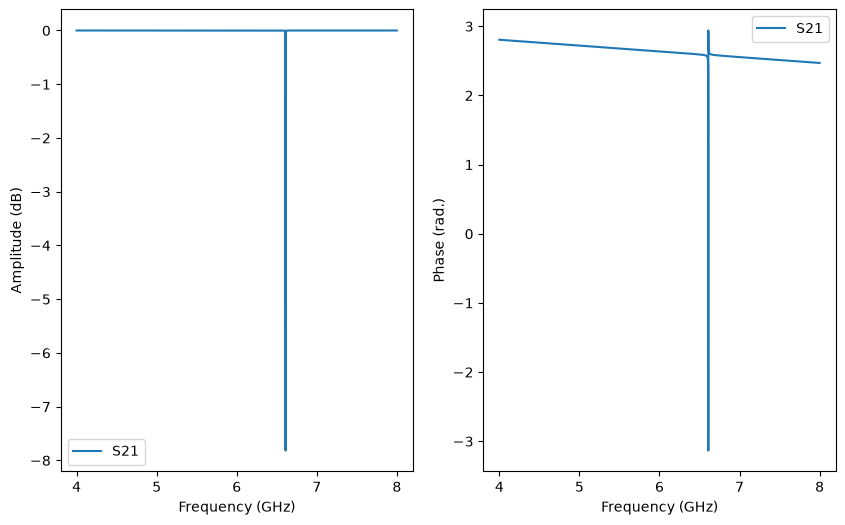

In [18]:
hfss.plot_params(["S21"])
# make sure that you can see a dip in S21. If not, change the frequency sweep region or decrease the MaxLength of the mesh and retry.
# Or you can even try an interpolating sweep

In [19]:
hfss.get_convergences()  # Make sure that it converges

(             Solved Elements  Max Mag. Delta S
 Pass Number                                   
 1                      10461               NaN
 2                      13605          0.588460
 3                      15651          0.273990
 4                      19294          0.112710
 5                      25044          0.062447
 6                      32552          0.027129
 7                      42316          0.013917
 8                      54984          0.007477
 9                      71437          0.005460
 10                     92833          0.004821,
 None,
 "DesignVariation : Cj='0fF' Lj='10nH'\nSetup : Sweep_DrivenModal_setup\n\n==================\nNumber of Passes\nCompleted : 10\nMaximum   : 18\nMinimum   : 2\n==================\nCriterion : Max Mag. Delta S\nTarget    : 0.005\nCurrent   : 0.0048209\nTarget Consecutive Passes  : 1\nCurrent Consecutive Passes : 1\nConverged : Yes\n==================\nPass Number|Solved Elements|Max Mag. Delta S|\n          1|    

In [20]:
# extract the S21 parameters
freqs, Pcurves, Pparams = hfss.get_params(["S21"])
# find argmin
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res  # If the dip at f_res is not deep enough to be the minimum in the plot, try to eyeball its location and set it here. A better way would be to use scipy's find_peaks functionality

6609600000.0

## Narrow sweep around the resonance found above

In [21]:
em1.setup.sweep_setup.start_ghz = np.round(f_res / 1e9, 5) - 0.05
em1.setup.sweep_setup.stop_ghz = np.round(f_res / 1e9, 5) + 0.05
em1._analyze()

INFO 12:24PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:24PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:24PM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


(                        S21
 6.55960 -0.848253+0.529582j
 6.55961 -0.848251+0.529584j
 6.55962 -0.848250+0.529586j
 6.55963 -0.848249+0.529588j
 6.55964 -0.848248+0.529590j
 ...                     ...
 6.65956 -0.851225+0.524683j
 6.65957 -0.851224+0.524685j
 6.65958 -0.851223+0.524687j
 6.65959 -0.851222+0.524689j
 6.65960 -0.851220+0.524691j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

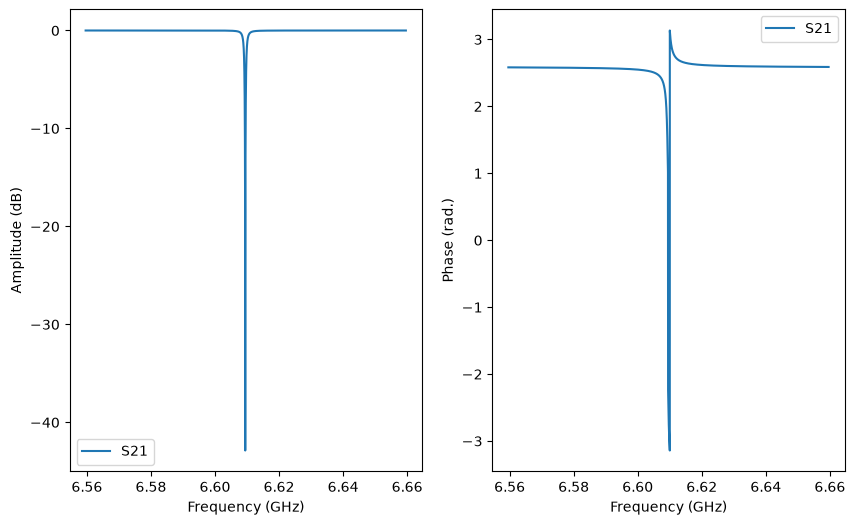

In [22]:
hfss.plot_params(["S21"])

In [23]:
freqs, Pcurves, Pparams = hfss.get_params(["S21"])

In [24]:
# find argmin
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

6609440000.0

## Very-Narrow sweep around the resonance found above

In [25]:
em1.setup.sweep_setup.start_ghz = np.round(f_res / 1e9, 5) - 0.005
em1.setup.sweep_setup.stop_ghz = np.round(f_res / 1e9, 5) + 0.005
em1._analyze()

INFO 12:25PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:25PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:25PM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


(                         S21
 6.604440 -0.809002+0.584036j
 6.604441 -0.808993+0.584047j
 6.604442 -0.808984+0.584058j
 6.604443 -0.808975+0.584069j
 6.604444 -0.808966+0.584080j
 ...                      ...
 6.614436 -0.882191+0.464959j
 6.614437 -0.882185+0.464972j
 6.614438 -0.882180+0.464985j
 6.614439 -0.882174+0.464998j
 6.614440 -0.882168+0.465011j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

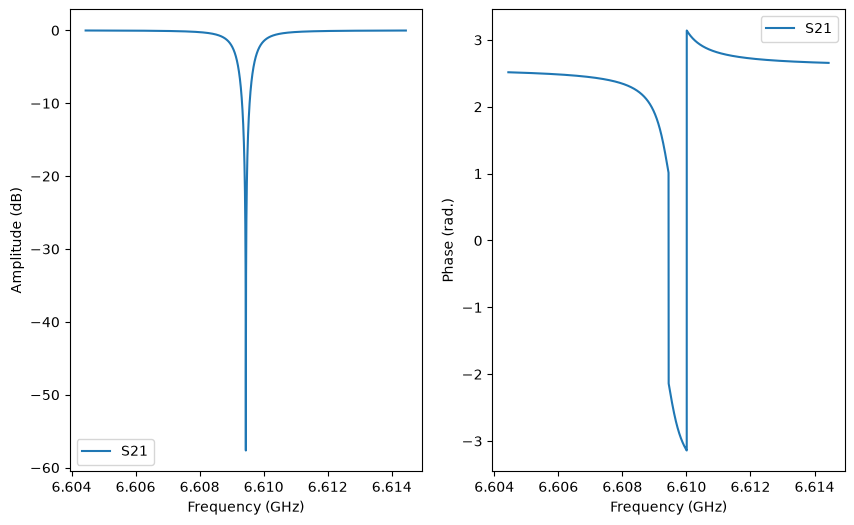

In [26]:
hfss.plot_params(["S21"])

In [27]:
freqs, Pcurves, Pparams = hfss.get_params(["S21"])

In [28]:
from qiskit_metal.analyses.em.transmission_fitting import fit_transmission

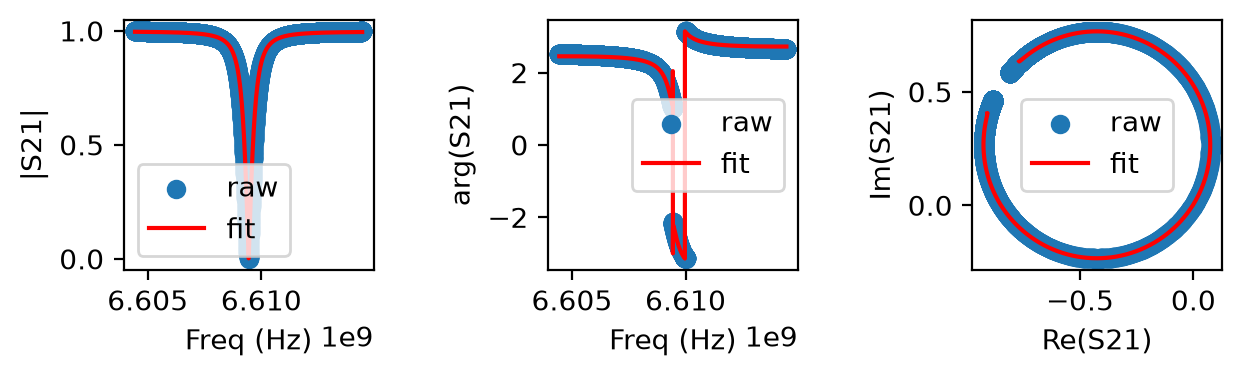

({'amplitude_complex': (-0.809002401973614+0.5840359337862799j),
  'Qr': 10191.551970992787,
  'Qc': 10213.1950215804,
  'fr': 6609441122.818479,
  'phi0': 0.003995190176797793,
  'delay': -2.2309874219812403e-09},
 [<Figure size 640x480 with 3 Axes>,
  array([<Axes: xlabel='Freq (Hz)', ylabel='|S21|'>,
         <Axes: xlabel='Freq (Hz)', ylabel='arg(S21)'>,
         <Axes: xlabel='Re(S21)', ylabel='Im(S21)'>], dtype=object)])

In [29]:
fit_transmission(
    freqs, Pparams.S21.values
)  # This fits the transmission, plots the fit over the raw data, and returns only the parameters best fit parameters and plots

In [30]:
# This fits the transmission, but does not generate the plot. Also, returns the fit parameters as a vector and the associated covariance matrix
fit_dict, _, fit_vec, fit_cov = fit_transmission(
    freqs, Pparams.S21.values, full_output=True, plot=False
)

# To obtain the standard deviations from the covariance matrix, use the below
np.sqrt(np.diag(fit_cov))

array([2.66352062e-04, 1.46983257e-09, 1.34777775e-09, 5.94452690e-12,
       1.30498224e-09, 8.11342234e-04, 6.42795248e-15])

## Close connections

In [31]:
# from qiskit_metal import q13

In [18]:
em1.close()

Warning! 3 COM references still alive
Ansys will likely refuse to shut down


In [19]:
hfss.disconnect_ansys()

Warning! 3 COM references still alive
Ansys will likely refuse to shut down


In [34]:
# gui.main_window.close()